In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import joblib
from tensorflow.keras.models import load_model
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models
from pydub import AudioSegment
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
# Cutting Audios Based on The Metadata

df = pd.read_csv('WCMED-Metadata/WCMED_ Metadata.csv')
output_dir = "audios"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for i, row in df.iterrows():
    audio = AudioSegment.from_file(f"./CPTR330FinalProjAudios/CPTR330FinalProj/{row['songName']}.mp3")
    start_ms = row['start_point'] * 1000
    end_ms = row['stop_point'] * 1000
    segment = audio[start_ms:end_ms]
    output_path = os.path.join(output_dir, row["fileName"])    
    segment.export(output_path, format="mp3")
    print(f"Creat {row['fileName']}")

NameError: name 'os' is not defined

In [61]:
def create_dataset(csv_path, audio_folder, n_mfcc=40, max_pad_len=173):
    df = pd.read_csv(csv_path)
    # Normalize ratings from [-1, 1] to [0, 1] for the sigmoid output
    y_values = (df["rating"].values + 1) / 2 
    
    X = []
    valid_y = []

    print(f"Processing {len(df)} files...")

    for idx, row in df.iterrows():
        file_path = Path(audio_folder) / row['name']
        
        if file_path.exists():
            try:
                # 1. Load Audio (30 seconds)
                audio, sr = librosa.load(file_path, duration=30)
                
                # 2. Extract MFCCs
                # Result shape: (n_mfcc, time)
                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
                
                # 3. THE AROUSAL HACK: Extract RMS Energy (Loudness)
                # This helps the model "hear" the dynamics/volume shifts
                rms = librosa.feature.rms(y=audio) # Shape: (1, time)
                
                # 4. Concatenate MFCC and RMS
                # We now have 41 features per time step
                features = np.vstack((mfcc, rms)) 
                
                # 5. Transpose to get (Time, Features)
                features = features.T 
                
                # 6. Standardize the Time Dimension (Padding/Trimming)
                if features.shape[0] < max_pad_len:
                    pad_width = max_pad_len - features.shape[0]
                    # Pad the time axis (0), leave feature axis (1) alone
                    features = np.pad(features, pad_width=((0, pad_width), (0, 0)), mode='constant')
                else:
                    features = features[:max_pad_len, :]
                
                # 7. Add Channel Dimension for your Conv2D-style input_shape
                # Result: (Time, Features, 1)
                features = features[..., np.newaxis]
                
                X.append(features)
                valid_y.append(y_values[idx])
                
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
        else:
            print(f"Warning: {file_path} not found. Skipping.")

    return np.array(X), np.array(valid_y)

X, y = create_dataset("./WCMED-Ratings/WCMED_Arousal_Rating.csv", "./audios/")

Processing 400 files...


In [62]:
X.shape

(399, 173, 41, 1)

In [46]:

def remove_features(A, percent):
    A_2d = np.squeeze(A) 
    U, S, Vh = np.linalg.svd(A_2d, full_matrices=False)
    L_M = np.zeros(A_2d.shape)
    k = int(round(percent * len(S)))
    
    for i in range(k):
        col_u = U[:, i].reshape(-1, 1) 
        row_v = Vh[i, :].reshape(1, -1)
        M = col_u @ row_v
        M = S[i] * M
        L_M = L_M + M
    
    return L_M

reduced_feats = []
for A in X:
    reduced_feats.append(remove_features(A, 0.5))
reduced_feats = np.array(reduced_feats)


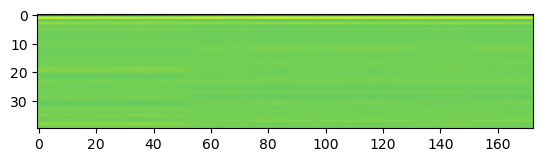

In [44]:
plt.imshow(reduced_feats[1])

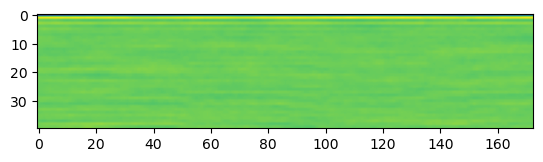

In [45]:
plt.imshow(X[1])

In [48]:
import soundfile as sf

def reduced_mfcc_to_audio(mfcc_matrix, sr=22050, n_mels=128):
    # 1. Squeeze to make sure it's 2D (n_mfcc, time)
    mfcc_2d = np.squeeze(mfcc_matrix)
    
    # 2. Convert MFCC back to a Mel Spectrogram
    # This is the inverse of the Discrete Cosine Transform
    mel_spec = librosa.feature.inverse.mfcc_to_mel(mfcc_2d, n_mels=n_mels)
    
    # 3. Convert Mel Spectrogram back to a Power Spectrogram
    S = librosa.feature.inverse.mel_to_stft(mel_spec)
    
    # 4. Use Griffin-Lim to estimate the phase and create the waveform
    # This "reconstructs" the audio from the magnitude
    y_reconstructed = librosa.griffinlim(S)
    
    return y_reconstructed

# Example: Convert the first reduced feature back to audio
audio_out = reduced_mfcc_to_audio(X[1])

# Save it to listen to the "SVD-cleaned" version
sf.write('reduced_audio_sample.wav', audio_out, 22050)

In [58]:
def reduce_audio_direct(file_path, percent=0.5):
    # 1. Load the audio
    y, sr = librosa.load(file_path, duration=30)
    
    # 2. Convert to a 2D Spectrogram (Magnitude)
    # stft returns complex numbers; we separate magnitude and phase
    stft = librosa.stft(y)
    magnitude, phase = librosa.magphase(stft)
    
    # 3. Apply your SVD Loop Logic to the magnitude matrix
    U, S, Vh = np.linalg.svd(magnitude, full_matrices=False)
    
    L_M = np.zeros(magnitude.shape)
    k = int(round(percent * len(S)))
    
    for i in range(k):
        # Your specific loop logic
        col_u = U[:, i].reshape(-1, 1)
        row_v = Vh[i, :].reshape(1, -1)
        L_M = L_M + (S[i] * (col_u @ row_v))
        
    # 4. Reconstruct the audio
    # Combine the reduced magnitude with the original phase
    resynthesized_stft = L_M * phase
    y_reduced = librosa.istft(resynthesized_stft)
    
    return y_reduced, sr

# Usage
new_audio, sr = reduce_audio_direct("./audios/Tchaikovsky_Op062_114_20100627-SMD_1.mp3", percent=0.009) # 10% for dramatic effect
sf.write('svd_compressed_audio.wav', new_audio, sr)

In [54]:
# Scaling
n_files, n_steps, n_feat = X.shape
X_flat = X.reshape(-1, n_feat)
scaler = StandardScaler()
X_scaled_flat = scaler.fit_transform(X_flat)
X = X_scaled_flat.reshape(n_files, n_steps, n_feat)

# Spliting


ValueError: too many values to unpack (expected 3)

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
#model = models.Sequential([
#layers.LSTM(64, 
#            input_shape=(60, 120), 
#            dropout=0.2,
#           ),
    # layers.Dropout(0.25),
#   layers.Dense(128, activation='relu'),
#    layers.Dense(1, activation='sigmoid')
#])

In [65]:
input_shape = (X.shape[1], X.shape[2], 1)

In [66]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

class SequentialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(SequentialAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight', 
                                 shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.b = self.add_weight(name='att_bias', 
                                 shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)
        super(SequentialAttention, self).build(input_shape)

    def call(self, x):
        # e = tanh(Wx + b) -> computes a score for every time step
        e = K.tanh(K.dot(x, self.W) + self.b)
        e = K.squeeze(e, axis=-1)
        alpha = K.softmax(e) # Normalizes scores so they sum to 1
        alpha = K.expand_dims(alpha, axis=-1)
        return K.sum(x * alpha, axis=1)

In [80]:
model = models.Sequential([
    # Step A: Handle your (Time, Freq, 1) input
    layers.Input(shape=input_shape),
    layers.Reshape((input_shape[0], input_shape[1])), # Result: (173, 40)
    
    # Step B: Frequency Importance (Per-Frame Feature Importance)
    # This Dense layer learns which of the 40 MFCCs correlate to Arousal.
    # It acts as a "feature selector" before the LSTM.
    layers.TimeDistributed(layers.Dense(64, activation='relu')),
    layers.BatchNormalization(),
    
    # Step C: Temporal Modeling
    layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2)),
    
    # Step D: Temporal Importance (Finding the 'loud' or 'high energy' moments)
    # Instead of just taking the last state, we weight the important seconds.
    SequentialAttention(),
    
    # Step E: Regression Head
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

In [81]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer='adam', loss='mse', metrics=['mae','mse'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_1 (Reshape)         (None, 173, 41)           0         
                                                                 
 time_distributed_1 (TimeDis  (None, 173, 64)          2688      
 tributed)                                                       
                                                                 
 batch_normalization_1 (Batc  (None, 173, 64)          256       
 hNormalization)                                                 
                                                                 
 bidirectional_1 (Bidirectio  (None, 173, 128)         66048     
 nal)                                                            
                                                                 
 sequential_attention_1 (Seq  (None, 128)              301       
 uentialAttention)                                    

In [82]:
history = model.fit(X_train, y_train, epochs=80, validation_data = (X_test, y_test))

Epoch 1/80
10/10 [==============================] - 6s 194ms/step - loss: 0.0495 - mae: 0.1784 - mse: 0.0495 - val_loss: 0.1159 - val_mae: 0.2656 - val_mse: 0.1159
Epoch 2/80
10/10 [==============================] - 1s 60ms/step - loss: 0.0383 - mae: 0.1481 - mse: 0.0383 - val_loss: 0.1302 - val_mae: 0.2875 - val_mse: 0.1302
Epoch 3/80
10/10 [==============================] - 1s 58ms/step - loss: 0.0328 - mae: 0.1400 - mse: 0.0328 - val_loss: 0.0956 - val_mae: 0.2398 - val_mse: 0.0956
Epoch 4/80
10/10 [==============================] - 1s 57ms/step - loss: 0.0313 - mae: 0.1385 - mse: 0.0313 - val_loss: 0.0745 - val_mae: 0.2099 - val_mse: 0.0745
Epoch 5/80
10/10 [==============================] - 1s 57ms/step - loss: 0.0320 - mae: 0.1413 - mse: 0.0320 - val_loss: 0.0663 - val_mae: 0.1971 - val_mse: 0.0663
Epoch 6/80
10/10 [==============================] - 1s 58ms/step - loss: 0.0313 - mae: 0.1349 - mse: 0.0313 - val_loss: 0.0617 - val_mae: 0.1877 - val_mse: 0.0617
Epoch 7/80
10/10 [===

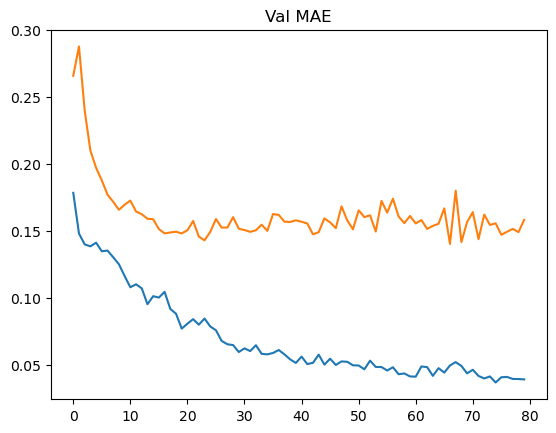

In [83]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Val MAE')

plt.show()

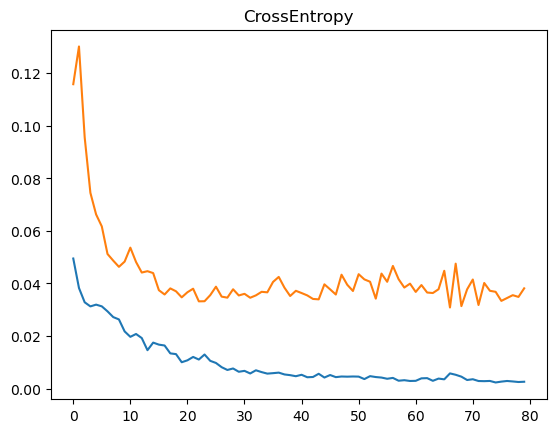

In [84]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CrossEntropy')

plt.show()

1/1 [==============================] - 1s 1s/step


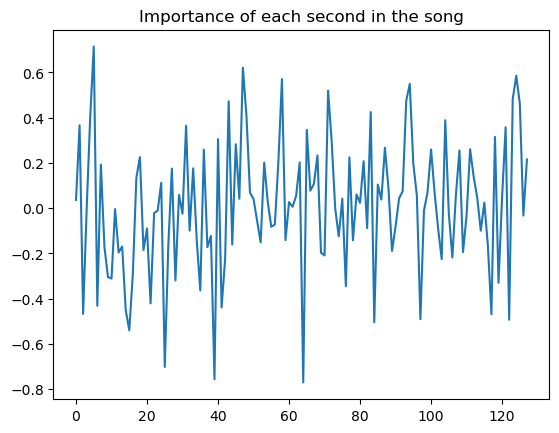

In [89]:
# 1. Create a model that outputs the 'alpha' weights
# We have to 'reach into' the SequentialAttention layer
# (Assuming 'model' is your trained Sequential model)

# Define a sub-model that stops right at the attention calculation
# Note: You might need to modify your custom layer to output 'alpha' for this to be easy
layer = [l for l in model.layers if "sequential_attention" in l.name][0]
debug_model = models.Model(inputs=model.input, 
                           outputs=layer.output)

# 2. Get weights for a specific song
sample_song = X[0:1] # Take the first song in your dataset
attention_scores = debug_model.predict(sample_song) 

# If you modified the layer to return alpha, you can plot it:
import matplotlib.pyplot as plt
plt.plot(attention_scores[0])
plt.title("Importance of each second in the song")
plt.show()

13/13 [==============================] - 1s 28ms/step


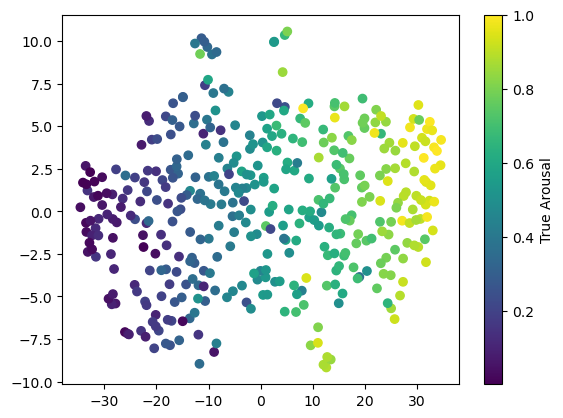

In [92]:
from sklearn.manifold import TSNE

# 1. Create a model that outputs the layer BEFORE the final Dense(1)
embedding_model = models.Model(inputs=model.input, 
                               outputs=model.get_layer('dense_5').output)

# 2. Extract embeddings for your whole dataset
embeddings = embedding_model.predict(X)

# 3. Reduce dimensions to 2D using t-SNE
tsne = TSNE(n_components=2, perplexity=30)
low_dim_embed = tsne.fit_transform(embeddings)

# 4. Plot and color by the TRUE rating
plt.scatter(low_dim_embed[:, 0], low_dim_embed[:, 1], c=y, cmap='viridis')
plt.colorbar(label='True Arousal')
plt.show()

(array([19., 20., 20., 20., 20., 21., 20., 20., 20., 19., 21., 20., 20.,
        20., 19., 21., 20., 19., 21., 20.]),
 array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,
         0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ]),
 <BarContainer object of 20 artists>)

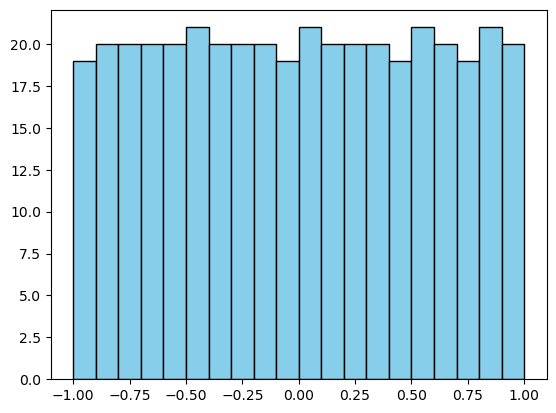

In [71]:
arousal = pd.read_csv("./WCMED-Ratings/WCMED_Arousal_Rating.csv")
df_sorted = arousal.sort_values(by=['rating'], ignore_index=True)
plt.hist(arousal["rating"], bins=20, range=(-1, 1), edgecolor='black', color='skyblue')

In [11]:
model.save("./Classv1/")

INFO:tensorflow:Assets written to: ./Classv1/assets


INFO:tensorflow:Assets written to: ./Classv1/assets
